### Load models

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from faiss_attn.source.modeling_llama import LlamaForCausalLM
import torch
import os
DEVICE = "cuda:0"

MODEL_DIR = "/public/home/sjtu_hansenyu/PretrainedModels/Llama-3.2-3B-Instruct"
model_name = os.path.basename(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
model = LlamaForCausalLM.from_pretrained(
    MODEL_DIR, 
    local_files_only=True, 
    device_map=DEVICE, 
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
)
n_layers = model.config.num_hidden_layers
n_heads = model.config.num_attention_heads
n_kv_heads = model.config.num_key_value_heads
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. Fr

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaFlashAttention2(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (no

In [3]:
# used for highlighting our retrieval heads
retrieval_heads = [(14, 22), (2, 16), (14, 2), (14, 1), (5, 7), (2, 15), (5, 6), (8, 2), (18, 18), (26, 21)]

### 1. Calculating contributions of frequency components

In [4]:
from faiss_attn.source.utils import get_static_attention_kernel_Mm
from tqdm import trange, tqdm
import numpy as np

head_freq_kernels = []
layer_idx = 14
for head_idx in trange(n_heads):
    freq_kernels = []
    for freq_idx in range(model.config.hidden_size // model.config.num_attention_heads // 2):
        M_matrix = get_static_attention_kernel_Mm(model, layer_idx, head_idx, distance_n=-4096, m_pair_idx=freq_idx)
        freq_kernels.append(M_matrix)
    head_kernel = torch.stack(freq_kernels, dim=0)  # (num_freqs, H, H)
    head_freq_kernels.append(head_kernel)
head_freq_kernels = torch.stack(head_freq_kernels, dim=0).cpu().float().numpy()  # (num_heads, num_freqs, H, H)
torch.cuda.empty_cache()
print(head_freq_kernels.shape)

100%|██████████| 24/24 [00:01<00:00, 22.98it/s]


(24, 64, 3072, 3072)


#### Head Frequency Kernel Energy in Certain Layer

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:47<00:00,  1.98s/it]


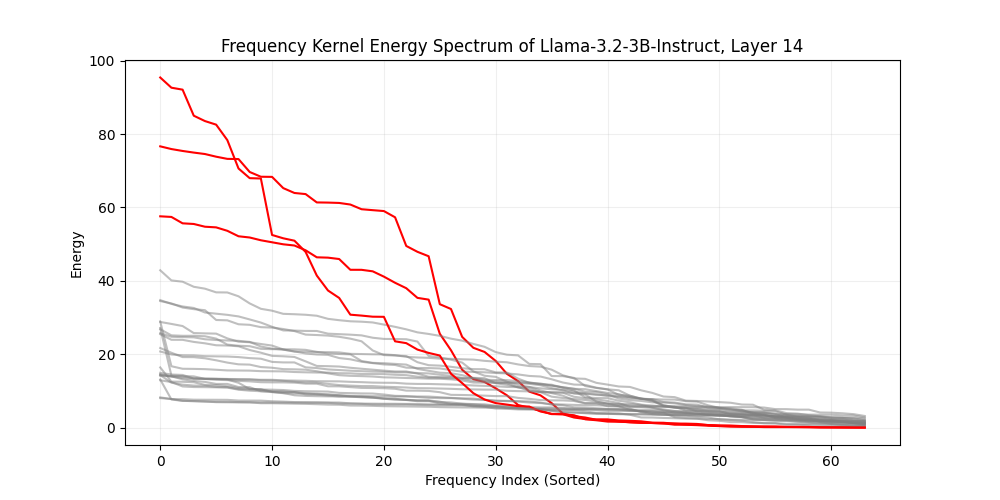

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mplcursors

focus = []
# Visualization: Energy Spectrum (replace SVD)
plt.figure(figsize=(10, 5))
lines = []
for head_idx in trange(n_heads):
    norms = (head_freq_kernels[head_idx] ** 2).sum((-1, -2))  # (num_freqs,)
    sorted_norms = np.sort(norms)[::-1]

    # effective rank
    p = norms / (norms.sum() + 1e-12)
    effective_rank = float(np.exp(-np.sum(p * np.log(p + 1e-10))))
    concentration = (p * np.linspace(0, 1, len(norms))).sum()
    score_rank = (concentration ** 1.0) * (1 - effective_rank / len(norms))

    is_retrieval = (layer_idx, head_idx) in retrieval_heads + focus
    line, = plt.plot(sorted_norms, color=("red" if is_retrieval else "gray"), alpha=(1.0 if is_retrieval else 0.5))
    line.set_gid(head_idx)
    line._effective_rank = effective_rank
    line._concentration = concentration
    line._score_rank = score_rank
    lines.append(line)

cursor = mplcursors.cursor(lines, hover=True)

@cursor.connect("add")
def on_add(sel):
    head_idx = sel.artist.get_gid()
    er = getattr(sel.artist, "_effective_rank", float("nan"))
    concentration = getattr(sel.artist, "_concentration", float("nan"))
    score_rank = getattr(sel.artist, "_score_rank", float("nan"))
    sel.annotation.set_text(f"head_idx={head_idx}\neff_rank={er:.2f}\nconcentration={concentration:.4f}\nscore_rank={score_rank:.4f}")

# plt.yscale('log')
plt.title(f"Frequency Kernel Energy Spectrum of Llama-3.2-3B-Instruct, Layer {layer_idx}")
plt.xlabel("Frequency Index (Sorted)")
plt.ylabel("Energy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("figs/ska/llama3.2-3b-erank.pdf")

Symmetry score

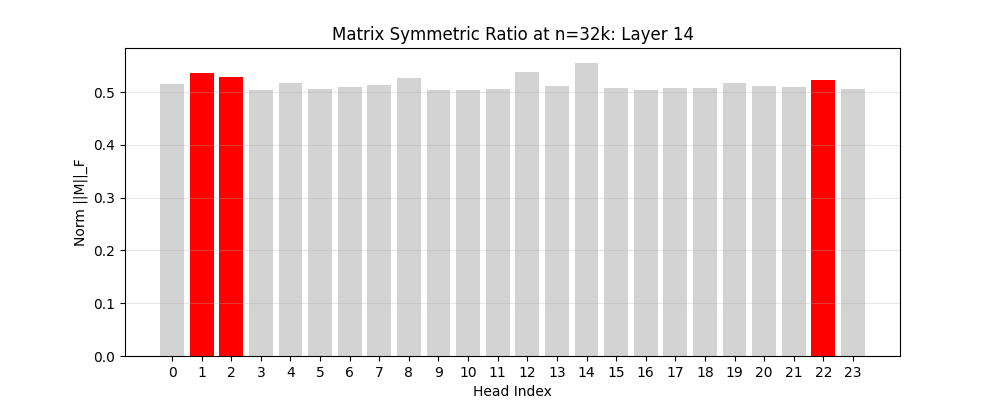

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mplcursors

head_kernels = head_freq_kernels.sum(axis=1)  # (n_heads, H, H)
colors = ['red' if (layer_idx, head_idx) in retrieval_heads else 'lightgray' for head_idx in range(n_heads)]
# Visualization: Symmetry of Frequency Kernels
sym_kernels = (head_kernels + head_kernels.transpose(0, 2, 1)) / 2
syms = np.linalg.norm(sym_kernels, axis=(-2, -1)) ** 2 / np.linalg.norm(head_kernels, axis=(-2, -1)) ** 2

plt.figure(figsize=(10, 4))
bars = plt.bar(range(n_heads), syms, color=colors)
plt.title(f"Matrix Symmetric Ratio: Layer {layer_idx}")
plt.xlabel("Head Index")
plt.ylabel("Norm ||M||_F")
plt.xticks(range(n_heads))
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Frequency Kernel Energy Heatmap

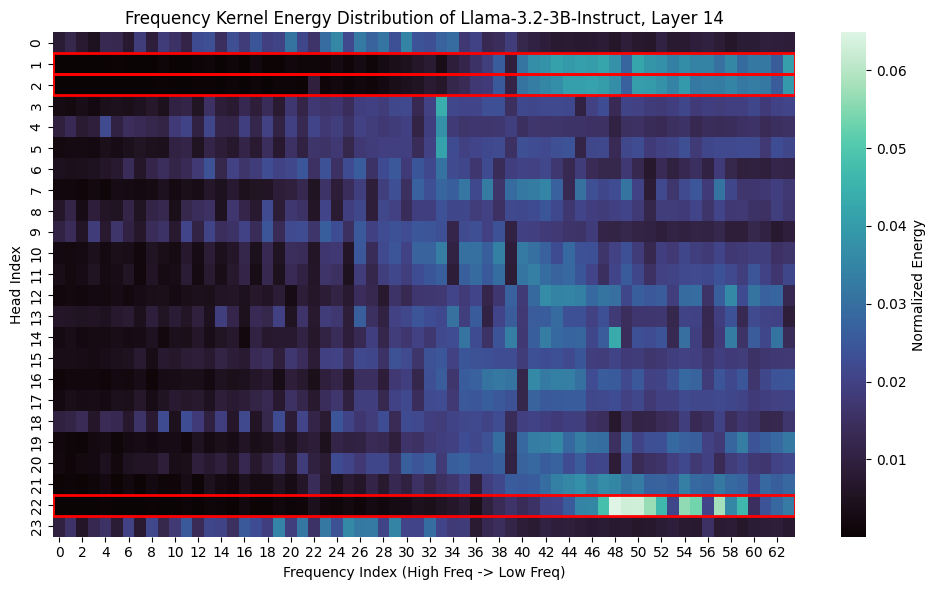

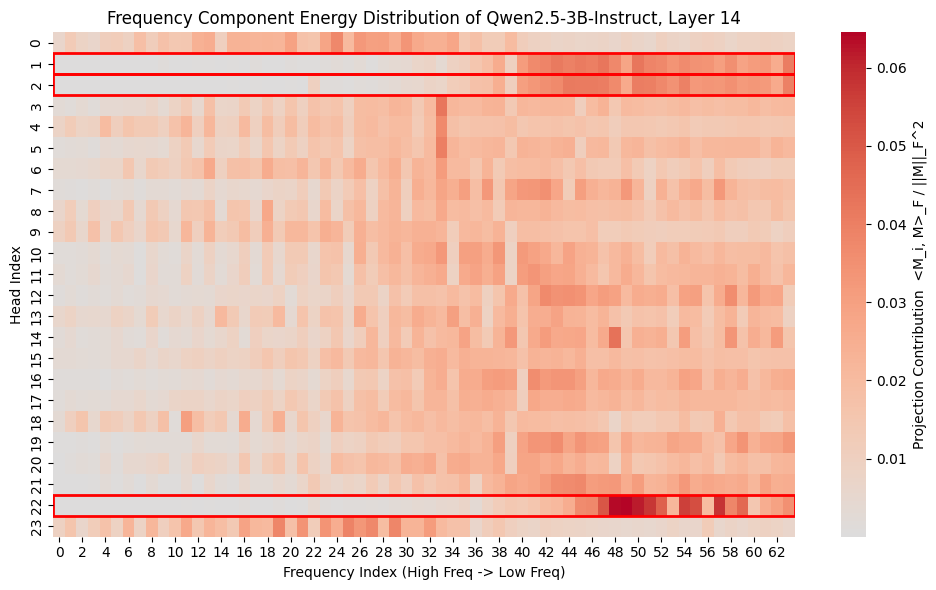

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualization 1: RoPE Frequency Energy Distribution (Heatmap)
freq_energy = np.linalg.norm(head_freq_kernels, ord="fro", axis=(-1, -2)) ** 2  # (n_heads, n_freqs)
# Normalize within each head (row-wise)
freq_energy = (freq_energy / (freq_energy.sum(axis=1, keepdims=True) + 1e-12))
plt.figure(figsize=(10, 6))
ax = sns.heatmap(freq_energy, cmap="mako", cbar_kws={'label': 'Normalized Energy'})
plt.title(f"Frequency Kernel Energy Distribution of Llama-3.2-3B-Instruct, Layer {layer_idx}")
plt.xlabel("Frequency Index (High Freq -> Low Freq)")
plt.ylabel("Head Index")
for l, h in retrieval_heads:
    if l != layer_idx:
        continue
    ax_hm = plt.gca()
    n_freqs = freq_energy.shape[1]
    ax_hm.add_patch(plt.Rectangle((0, h), n_freqs, 1, fill=False, edgecolor="red", linewidth=2))

plt.tight_layout()
plt.savefig("figs/ska/llama3.2-3b-freq-heatmap.pdf")
plt.show()

# Visualization 2: RoPE Frequency Component Contribution to Total Energy
head_kernels = head_freq_kernels.sum(axis=1)
total_energy = np.linalg.norm(head_kernels, ord="fro", axis=(-1, -2)) ** 2 + 1e-12  # (n_heads,)
projections = (head_freq_kernels * head_kernels[:, None, :, :]).sum(axis=(-1, -2))  # (n_heads, n_freqs)
proj_contrib = projections / total_energy[:, None]  # (n_heads, n_freqs)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    proj_contrib,
    cmap="coolwarm",
    center=0.0,
    cbar_kws={'label': 'Projection Contribution  <M_i, M>_F / ||M||_F^2'}
)
plt.title(f"Frequency Component Energy Distribution of Llama-3.2-3B-Instruct, Layer {layer_idx}")
plt.xlabel("Frequency Index (High Freq -> Low Freq)")
plt.ylabel("Head Index")

# Highlight retrieval heads
for l, h in retrieval_heads:
    if l != layer_idx:
        continue
    ax_hm = plt.gca()
    n_freqs = proj_contrib.shape[1]
    ax_hm.add_patch(plt.Rectangle((0, h), n_freqs, 1, fill=False, edgecolor="red", linewidth=2))

plt.tight_layout()
plt.show()

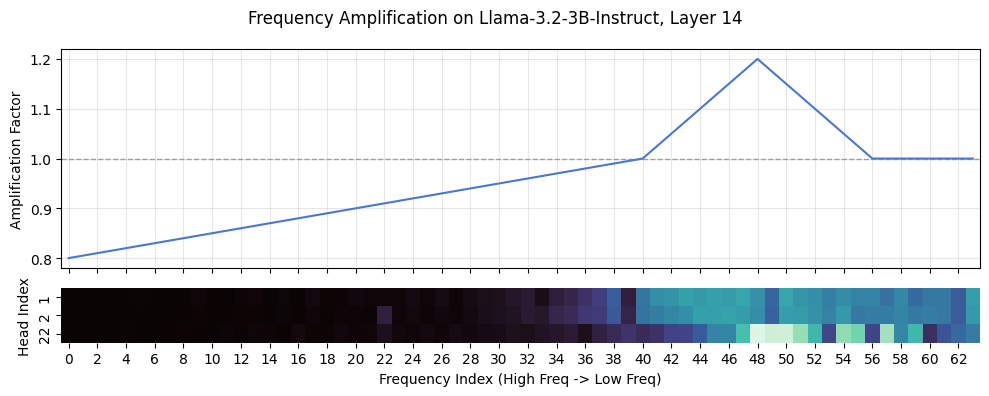

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
fig, (ax_line, ax_heat) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(10, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

selected_freqs = [1, 2, 22]
ax_heat = sns.heatmap(freq_energy[selected_freqs], cmap="mako", cbar=False)
ax_heat.set_yticks(np.arange(3) + 0.5)
ax_heat.set_yticklabels(selected_freqs)
ax_heat.set_ylabel('Head Index')
ax_heat.set_title('', fontsize=0)

freq_multiplier = np.concatenate([
    np.linspace(0.8, 1.0, num=40, endpoint=False),
    np.linspace(1.0, 1.2, num=8, endpoint=False),
    np.linspace(1.2, 1.0, num=8, endpoint=False),
    np.linspace(1.0, 1.0, num=8, endpoint=False),
])

ax_line.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax_line.plot(
    np.arange(64) + 0.5, freq_multiplier, 
    color='#4878d0',
    linestyle='-'
)
ax_line.set_ylabel('Amplification Factor')
ax_line.grid(True, alpha=0.3) 

ax_heat.set_xticks(np.arange(0, 64, 2) + 0.5)
ax_heat.set_xticklabels(np.arange(0, 64, 2), fontsize=10)
ax_heat.set_xlabel('Frequency Index (High Freq -> Low Freq)')

fig.suptitle("Frequency Amplification on Llama-3.2-3B-Instruct, Layer 14")
plt.tight_layout()
plt.savefig('figs/multiplier_llama.pdf', bbox_inches='tight')
plt.show()

### 2. Modify the model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from faiss_attn.source.modeling_llama import LlamaForCausalLM
import torch
import os
from torch import nn
DEVICE = "cuda:0"

MODEL_DIR = "~/PretrainedModels/Llama-3.2-3B-Instruct"
model_name = os.path.basename(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
modified_model = LlamaForCausalLM.from_pretrained(
    MODEL_DIR, 
    local_files_only=True, 
    device_map=DEVICE, 
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
)
n_layers = modified_model.config.num_hidden_layers
n_heads = modified_model.config.num_attention_heads
hidden_size = modified_model.config.hidden_size
head_dim = hidden_size // n_heads
modified_model.eval()

LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. Fr

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaFlashAttention2(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    

In [9]:
modified_heads = [
    (14, 22), (2, 16), (14, 2), (14, 1), (5, 7), (2, 15), (5, 6), (8, 2), (18, 18), (26, 21), 
    # (16, 15), (26, 22), (12, 3), (5, 8), (15, 18), (26, 8), (18, 15), (15, 19), (15, 7), (6, 1), 
    # (27, 16), (26, 11), (1, 9), (26, 16), (26, 9), (10, 3), (17, 11), (12, 20), (23, 10), (18, 19)
]     # Llama-3.2-3b-instruct
len(modified_heads)

10

#### Modification functions

In [ ]:
from typing import List
import numpy as np

@torch.no_grad()
def modify_q_proj(
    model, 
    layer_idx: int, 
    head_idx_list: List[int], 
    freq_multiplier: np.array,
) -> torch.Tensor:
    # 1. get basic config
    config = model.config
    hidden_size = config.hidden_size
    num_heads = config.num_attention_heads
    head_dim = hidden_size // num_heads
    
    if freq_multiplier.ndim == 2:
        assert freq_multiplier.shape[0] == len(head_idx_list), f"freq_multiplier first dim {freq_multiplier.shape[0]} does not match head_idx_list length {len(head_idx_list)}"
    if freq_multiplier.shape[-1] != head_dim // 2:
        raise ValueError(f"freq_multiplier length {freq_multiplier.shape[0]} does not match head_dim/2 {head_dim // 2}")

    # 2. get the Attention module of that layer
    if hasattr(model, "model"):
        layers = model.model.layers
    else:
        layers = model.layers

    layer = layers[layer_idx]
    attn = layer.self_attn

    # 3. extract specific rows of W_Q
    # Llama's Linear weight shape is (out_features, in_features)
    # W_Q_all shape: (num_heads * head_dim, hidden_size)
    W_Q_all = torch.clone(attn.q_proj.weight.data)
    for i, head_idx in enumerate(head_idx_list):
        q_start = head_idx * head_dim
        multiplier = freq_multiplier if freq_multiplier.ndim == 1 else freq_multiplier[i]
        # 4. apply the multiplier to the specific rows corresponding to the head_idx
        # x1 = x[..., :half], x2 = x[..., half:]
        half_dim = head_dim // 2
        for m_pair_idx in range(half_dim):
            idx1 = m_pair_idx
            idx2 = m_pair_idx + half_dim
            W_Q_all[[q_start + idx1, q_start + idx2], :] *= multiplier[m_pair_idx]

    return W_Q_all

#### Amplify low-frequency components

In [ ]:
import random
random_heads = [(i, j) for i in range(n_layers) for j in range(n_heads)]
random.shuffle(random_heads)
random_heads = random_heads[:len(modified_heads)]

low, high = 0.8, 1.2
freq_multiplier = np.concatenate([
    np.linspace(low, 1.0, num=40, endpoint=False),
    np.linspace(1.0, high, num=8, endpoint=False),
    np.linspace(high, 1.0, num=8, endpoint=False),
    np.linspace(1.0, 1.0, num=8, endpoint=False),
])
for l in range(n_layers):
    heads_to_modify = [h for (layer_h, h) in modified_heads if layer_h == l]
    if len(heads_to_modify) == 0:
        continue
    new_q = modify_q_proj(model, l, heads_to_modify, freq_multiplier)
    modified_model.model.layers[l].self_attn.q_proj.weight.data = new_q

#### Directly remove certain heads

In [ ]:
import random
random_heads = [(i, j) for i in range(n_layers) for j in range(n_heads)]
random.shuffle(random_heads)
random_heads = random_heads[:len(modified_heads)]

for l, h in modified_heads:
    modified_model.model.layers[l].self_attn.o_proj.weight.data[:, h * head_dim : (h + 1) * head_dim].fill_(0)

In [ ]:
tokenizer.save_pretrained(f"saved_models/Llama-3.2-3B-Instruct_top10_masked")
modified_model.save_pretrained(f"saved_models/Llama-3.2-3B-Instruct_top10_masked")

LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. Fr

### 3. Using LPS/RPS to detect long-context heads

In [8]:
import torch
import numpy as np
from tqdm import trange, tqdm
from faiss_attn.source.utils import get_static_attention_kernel_Mm

@torch.no_grad()
def calculate_symmetric_with_kernel_func(
    model,
    check_distance=-65536,
    kernel_func=get_static_attention_kernel_Mm,
    num_freqs=None,
):
    config = model.config
    num_layers = config.num_hidden_layers
    num_heads = config.num_attention_heads
    hidden_size = config.hidden_size
    head_dim = hidden_size // num_heads
    if num_freqs is None:
        rotary_pct = getattr(config, "rotary_pct", 1.0)
        num_freqs = int((head_dim * rotary_pct) // 2) if hasattr(config, "rotary_pct") else head_dim // 2
    
    results = {}
    
    print(f"Config: Layers={num_layers}, Heads={num_heads}, Distance={check_distance}, Kernel={kernel_func.__name__}, NumFreqs={num_freqs}")
    
    for layer_idx in trange(num_layers):
        layer_symmetric_scores = []
        for head_idx in range(num_heads):
            M_total = torch.zeros((hidden_size, hidden_size), device=model.device, dtype=torch.float32)
            for m in range(num_freqs):
                M_m = kernel_func(
                    model=model,
                    layer_idx=layer_idx,
                    head_idx=head_idx,
                    distance_n=check_distance,
                    m_pair_idx=m
                )
                M_total += M_m
            symmetric_M = (M_total + M_total.T) / 2.0
            symmetric_score = ((symmetric_M ** 2).sum() / ((M_total ** 2).sum() + 1e-9) - 0.5).abs().item()
            layer_symmetric_scores.append(symmetric_score)
        
        layer_symmetric_scores = np.array(layer_symmetric_scores)
        for h in range(num_heads):
            results[(layer_idx, h)] = layer_symmetric_scores[h]
    del M_m
    return {key: results[key] for key in sorted(results.keys(), key=lambda x: results[x], reverse=True)}


@torch.no_grad()
def calculate_lps_with_kernel_func(
    model,
    check_distance=-65536,
    kernel_func=get_static_attention_kernel_Mm,
    num_freqs=None,
    layer_normalize: bool = False,
    alpha: float=0.4,
):
    config = model.config
    num_layers = config.num_hidden_layers
    num_heads = config.num_attention_heads
    hidden_size = config.hidden_size
    head_dim = hidden_size // num_heads
    if num_freqs is None:
        rotary_pct = getattr(config, "rotary_pct", 1.0)
        num_freqs = int((head_dim * rotary_pct) // 2) if hasattr(config, "rotary_pct") else head_dim // 2
    
    results = {}
    
    print(f"Config: Layers={num_layers}, Heads={num_heads}, Distance={check_distance}, Kernel={kernel_func.__name__}, NumFreqs={num_freqs}")
    
    for layer_idx in trange(num_layers):
        layer_energy_scores = []
        layer_erank_scores = []
        for head_idx in range(num_heads):
            freq_energies = []
            for m in range(num_freqs):
                M_m = kernel_func(
                    model=model,
                    layer_idx=layer_idx,
                    head_idx=head_idx,
                    distance_n=check_distance,
                    m_pair_idx=m
                )
                # Calculate the energy of the components (Frobenius norm squared)
                m_energy = (M_m ** 2).sum().item()
                freq_energies.append(m_energy)
            freq_energies = np.array(freq_energies)

            if freq_energies.max() > 1e-9:
                # 1. Calculate effective rank
                probs = freq_energies / freq_energies.sum()
                effective_rank = np.exp(-(probs * np.log(probs + 1e-10)).sum())
                score_erank = 1 - effective_rank / len(probs)
                # 2. Calculate weighted energy ratio, with higher weights for lower frequencies
                score_energy = (probs * np.linspace(0, 1, len(probs))).sum()
            else:
                score_erank = 0.0
                score_energy = 0.0
            layer_erank_scores.append(score_erank)
            layer_energy_scores.append(score_energy)
        
        layer_energy_scores = np.array(layer_energy_scores)
        layer_erank_scores = np.array(layer_erank_scores)
        lps_scores = (layer_energy_scores ** alpha) * (layer_erank_scores ** (1 - alpha))
        normalized_scores = (lps_scores - lps_scores.mean()) / (lps_scores.std() + 1e-6)
        for h in range(num_heads):
            final_lps = lps_scores[h]
            results[(layer_idx, h)] = {
                "lps_score": final_lps,
                "normalized_lps_score": normalized_scores[h],
                "raw_energy": layer_energy_scores[h],
                "raw_erank": layer_erank_scores[h]
            }
    del M_m
    k = "lps_score" if not layer_normalize else "normalized_lps_score"
    return {key: results[key] for key in sorted(results.keys(), key=lambda x: results[x][k], reverse=True)}

In [9]:
lps_results = calculate_lps_with_kernel_func(model, check_distance=-32768, layer_normalize=False)
sym_results = calculate_symmetric_with_kernel_func(model, check_distance=-32768)

Config: Layers=28, Heads=24, Distance=-32768, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


100%|██████████| 28/28 [00:15<00:00,  1.81it/s]


Config: Layers=28, Heads=24, Distance=-32768, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


100%|██████████| 28/28 [00:12<00:00,  2.31it/s]


In [10]:
sym_penalty = 0.5
final_scores = {k: lps_results[k]["lps_score"] - sym_penalty * sym_results[k] for k in sorted(lps_results.keys(), key=lambda x: lps_results[x]["lps_score"] - sym_penalty * sym_results[x], reverse=True)}
print([k for k in list(final_scores.keys())[:30]])

[(14, 22), (2, 16), (14, 2), (14, 1), (5, 7), (2, 15), (5, 6), (8, 2), (26, 21), (18, 18), (16, 15), (26, 22), (12, 3), (5, 8), (15, 18), (18, 15), (26, 8), (15, 7), (15, 19), (6, 1), (27, 16), (1, 9), (26, 11), (26, 16), (26, 9), (10, 3), (17, 11), (12, 20), (23, 10), (24, 15)]


LPS at different relative distance

In [11]:
distances = [256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
lps_results_by_distance = {}
for dist in distances:
    lps_results_by_distance[dist] = calculate_lps_with_kernel_func(model, check_distance=-dist, layer_normalize=False)

Config: Layers=28, Heads=24, Distance=-256, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:15<00:00,  1.78it/s]


Config: Layers=28, Heads=24, Distance=-512, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


100%|██████████| 28/28 [00:15<00:00,  1.79it/s]


...

100%|██████████| 28/28 [00:15<00:00,  1.83it/s]


Config: Layers=28, Heads=24, Distance=-65536, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


100%|██████████| 28/28 [00:15<00:00,  1.77it/s]


Config: Layers=28, Heads=24, Distance=-131072, Kernel=get_static_attention_kernel_Mm, NumFreqs=64


100%|██████████| 28/28 [00:15<00:00,  1.85it/s]


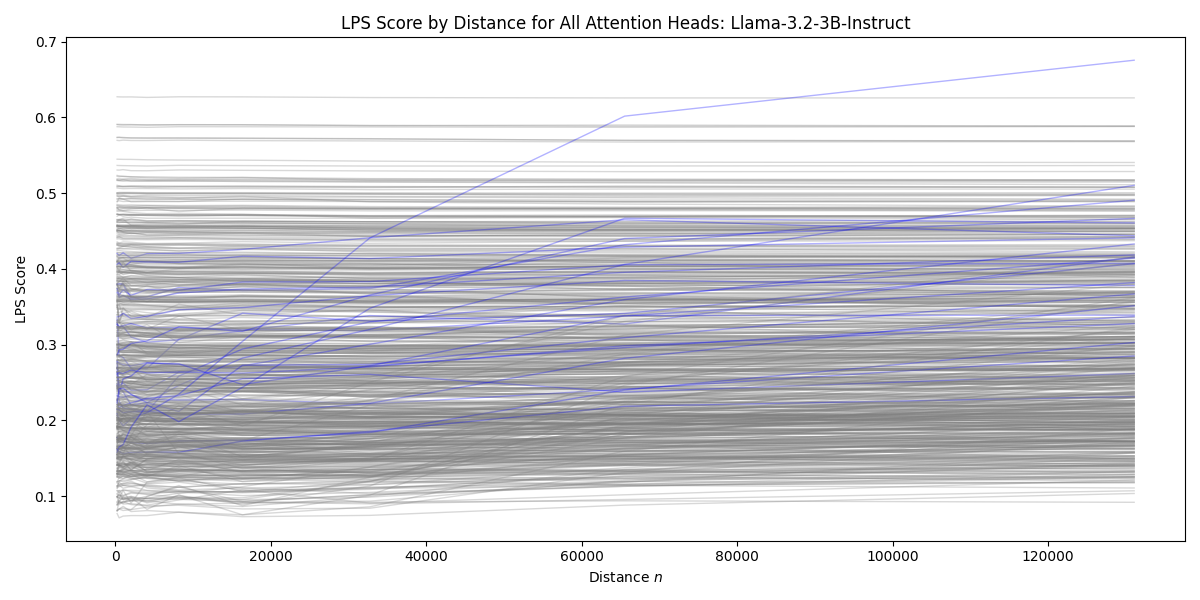

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

head_names = list(lps_results_by_distance[distances[0]].keys())
fig, ax = plt.subplots(figsize=(12, 6))
for head in head_names:
    y_scores = [lps_results_by_distance[d][head]["lps_score"] for d in distances]
    color = "blue" if head[0] == 0 else "gray"
    ax.plot(distances, y_scores, linewidth=1.0, alpha=0.3, color=color)
ax.set_xlabel("Distance $n$")
ax.set_ylabel("LPS Score")
ax.set_title("LPS Score by Distance for All Attention Heads: Llama-3.2-3B-Instruct")
# ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### 4. Run on actual long context

In [ ]:
# build needle-in-a-haystack evaluation context
from faiss_attn.source.utils import NIAHBuilder
context_builder = NIAHBuilder(tokenizer=tokenizer, haystack_dir="PaulGrahamEssays")

In [4]:
needle = "The best thing to do in Vancouver is watching sea at the convention center on a summer day."
question = "What is the best thing to do in Vancouver?"
# question = "Why does everyone likes Mr Green?"
input_str = context_builder.generate_context(context_len=65536, depth_ratio=0.8, needle_str=needle, question_str=question)
input_str += "The best thing to do in Vancouver is"
# input_str += "Mr Green is liked by everyone because he"
real_needle = "watching sea at the convention center on a summer day."
print(input_str[-500:])

Token indices sequence length is longer than the specified maximum sequence length for this model (148769 > 131072). Running this sequence through the model will result in indexing errors


aradise Lost is a
rock imitating a butterfly that happened to get fossilized.
Even Samuel Johnson seems to have balked at this, on the one  
hand paying Milton the compliment of an extensive biography,
and on the other writing of Paradise Lost that "none who read it
ever wished it longer."

Want to start</book>
Based on the content of the book, Question: What is the best thing to do in Vancouver?
Answer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>

The best thing to do in Vancouver is


In [133]:
del outputs, outputs_prefill, past_kv, softmax_attn_weights, attn_weights, topk_values, topk_indices, pair_attn_weights, pair_topk_indices, pair_topk_values, x_i_query, x_j_key
torch.cuda.empty_cache()

In [ ]:
import torch
import pandas as pd
import math

print("[Needle]", real_needle)
layer_idx = 14
with torch.no_grad():
    input_ids = tokenizer(input_str, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    print("Input length:", input_ids.shape[1])
    outputs_prefill = model(input_ids=input_ids[:,:-1], use_cache=True, return_dict=True)
    past_kv = outputs_prefill.past_key_values
    outputs = model(input_ids=input_ids[:,-1:], past_key_values=past_kv, use_cache=True, output_attentions=True, attn_mode="torch")
top_token_ids = outputs.logits[0, -1].topk(5)
print("Top predicted tokens for the next position:")
for score, token_id in zip(top_token_ids.values, top_token_ids.indices):
    token_str = tokenizer.decode(token_id.unsqueeze(0), skip_special_tokens=False)
    print(f"['{token_str}' {score.item():.4f}]", end=' ')

x_i_query = outputs["inspect"][layer_idx]["query"]      # (bsz=1, n_heads, seq_len=1, head_dim)
x_j_key = outputs["inspect"][layer_idx]["key"]      # (bsz=1, n_heads, seq_len, head_dim)
head_dim = x_i_query.shape[-1]
attn_weights = torch.matmul(x_i_query, x_j_key.transpose(2, 3))[0, :, 0] / math.sqrt(head_dim)  # unnormalized (num_heads, seq_len)
softmax_attn_weights = outputs.attentions[layer_idx]  # (batch_size=1, num_heads, seq_len, seq_len)
softmax_attn_weights = softmax_attn_weights[0, :, -1, :]  # (num_heads, seq_len)
topk_values, topk_indices = torch.topk(softmax_attn_weights, k=10, dim=-1)  # (num_heads, k)

x_i_query = torch.stack(
    (x_i_query[..., :x_i_query.shape[-1]//2], x_i_query[..., x_i_query.shape[-1]//2:]), dim=-1
).transpose(2, 3)    # (bsz=1, n_heads, n_head_dim_pairs, seq_len=1, 2)
x_j_key = torch.stack(
    (x_j_key[..., :x_j_key.shape[-1]//2], x_j_key[..., x_j_key.shape[-1]//2:]), dim=-1
).transpose(2, 3)    # (bsz=1, n_heads, n_head_dim_pairs, seq_len, 2)
pair_attn_weights = torch.matmul(x_i_query, x_j_key.transpose(3, 4)) / math.sqrt(head_dim)  # (bsz=1, n_heads, n_head_dim_pairs, seq_len=1, seq_len)

pair_attn_weights = pair_attn_weights[0, :, :, 0, :]  # (n_heads, n_head_dim_pairs, seq_len)
pair_topk_values, pair_topk_indices = torch.topk(pair_attn_weights, k=10, dim=-1)  # (n_heads, n_head_dim_pairs, k)
pair_indexed_values = pair_attn_weights.gather(-1, pair_topk_indices)  # (n_heads, n_head_dim_pairs, k)

def emphasize_if_in_needle(tok: str) -> str:
    disp = tok.replace("\n", "\\n")
    if tok.strip() and (tok.strip() in real_needle):
        return f"<b><span style='background-color:#ff4d4f;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    return disp
from IPython.display import display, HTML
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

[Needle] watching sea at the convention center on a summer day.


past_key_values should not be None in from_legacy_cache()


Input length: 65405
Top predicted tokens for the next position:
[' to' 23.8750] [' watching' 23.2500] [' "' 21.1250] [' watch' 19.0000] [' simply' 18.5000] 

In [ ]:
def emphasize_if_in_needle(tok: str) -> str:
    disp = tok.replace("\n", "\\n")
    if tok.strip() and (tok.strip() in real_needle):
        return f"<b><span style='background-color:#ff4d4f;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    elif tok.strip() and (tok.strip() == "<|begin_of_text|>"):
        return f"<b><span style='background-color:#1890ff;color:white;padding:1px 4px;border-radius:4px'>{disp}</span></b>"
    return disp

rows = []
for head_idx in range(n_heads):
    row = {
        "layer": layer_idx,
        "head": head_idx,
    }
    for r in range(topk_indices.shape[1]):
        token_pos = int(topk_indices[head_idx, r].item())
        tok_str = tokenizer.decode(input_ids[0, token_pos:token_pos + 1], skip_special_tokens=False)

        row[f"token#{r+1}"] = emphasize_if_in_needle(tok_str)
        row[f"attn#{r+1}"] = f"{topk_values[head_idx, r].item():.4f}"
        row[f"pos#{r+1}"] = token_pos
    rows.append(row)

df_attn = pd.DataFrame(rows, index=None)
display(HTML(df_attn.to_html(escape=False, index=False)))

layer,head,token#1,attn#1,pos#1,token#2,attn#2,pos#2,token#3,attn#3,pos#3,token#4,attn#4,pos#4,token#5,attn#5,pos#5,token#6,attn#6,pos#6,token#7,attn#7,pos#7,token#8,attn#8,pos#8,token#9,attn#9,pos#9,token#10,attn#10,pos#10
14,0,best,0.2012,65398,thing,0.1162,65399,<|begin_of_text|>,0.1099,0,do,0.0845,65401,The,0.0684,65397,is,0.0525,65404,Vancouver,0.0459,65403,in,0.0393,65402,to,0.0366,65400,<|start_header_id|>,0.0206,65393
14,1,<|begin_of_text|>,0.8984,0,<|start_header_id|>,0.0105,65393,The,0.0045,65397,<|eot_id|>,0.0041,65392,Answer,0.0025,65390,\n\n,0.0016,65396,is,0.0014,65404,:,0.0012,65391,watching,0.0012,52238,being,0.0006,51379
14,2,watching,0.9531,52238,unexpected,0.0062,52206,<|begin_of_text|>,0.0055,0,Even,0.0036,52250,rozen,0.0016,53349,everyday,0.0016,53433,purely,0.0013,59085,met,0.0011,53298,at,0.0011,52240,Charlie,0.0009,53299
14,3,Vancouver,0.2412,65388,<|begin_of_text|>,0.2236,0,do,0.0918,65401,is,0.0840,65404,to,0.0635,65400,?\n,0.0620,65389,Vancouver,0.0581,65403,thing,0.0415,65399,do,0.0220,65386,:,0.0211,65391
14,4,is,0.3164,65404,to,0.1030,65400,<|begin_of_text|>,0.0845,0,:,0.0786,65391,in,0.0649,65402,best,0.0479,65398,The,0.0356,65397,\n\n,0.0299,65396,?\n,0.0295,65389,Vancouver,0.0262,65403
14,5,to,0.1553,65400,?\n,0.1553,65389,Vancouver,0.1069,65388,is,0.0972,65404,:,0.0942,65391,The,0.0505,65397,do,0.0417,65401,do,0.0347,65386,\n\n,0.0320,65396,best,0.0315,65398
14,6,?\n,0.2012,65389,is,0.1895,65404,to,0.1338,65400,Vancouver,0.1060,65388,:,0.0718,65391,<|begin_of_text|>,0.0635,0,do,0.0339,65401,Vancouver,0.0330,65403,<|eot_id|>,0.0299,65392,thing,0.0221,65399
14,7,Vancouver,0.3730,65388,?\n,0.1104,65389,<|begin_of_text|>,0.0845,0,to,0.0820,65400,do,0.0459,65401,Vancouver,0.0425,65403,thing,0.0325,65399,:,0.0219,65391,best,0.0121,65398,in,0.0099,65387
14,8,<|begin_of_text|>,0.3223,0,is,0.0781,65404,do,0.0510,65401,best,0.0334,65398,in,0.0332,65402,Vancouver,0.0291,65403,thing,0.0281,65399,The,0.0265,65397,:,0.0253,65391,?\n,0.0237,65389
14,9,do,0.4121,65401,do,0.2832,65386,thing,0.0542,65399,in,0.0508,65387,in,0.0435,65402,thing,0.0281,65384,<|begin_of_text|>,0.0229,0,?\n,0.0193,65389,best,0.0100,65398,is,0.0093,65404


In [ ]:
# for a certain head top-10 attended tokens, show the attention contribution of each frequency
head_idx = 2
topk_token_indices = topk_indices[head_idx]  # (k,)
indexed_pair_topk_values = pair_attn_weights[head_idx, :, topk_token_indices]  # (n_head_dim_pairs, k)
rows = []
for dim_pair_idx in range(head_dim // 2):
    row = {
        "layer": layer_idx,
        "head": head_idx,
        "dim": dim_pair_idx,
    }
    ranked_pair_attn_weights = torch.argsort(pair_attn_weights[head_idx, dim_pair_idx], descending=True)
    sorted_indices = torch.argsort(indexed_pair_topk_values[dim_pair_idx], descending=True)
    for r, i in enumerate(sorted_indices):
        token_pos = int(topk_token_indices[i].item())
        tok_str = tokenizer.decode(input_ids[0, token_pos:token_pos + 1], skip_special_tokens=False)
        relative_attn = indexed_pair_topk_values[dim_pair_idx, i].item()
        # relative_attn = pair_topk_values[head_idx, dim_pair_idx, r].item() - pair_attn_weights[head_idx, dim_pair_idx].item()
        # relative_attn = pair_topk_values[head_idx, dim_pair_idx, r].item() - softmax_attn_weights[head_idx, r].item()

        row[f"token#{r+1}"] = emphasize_if_in_needle(tok_str)
        row[f"rank#{r+1}"] = (ranked_pair_attn_weights == token_pos).nonzero(as_tuple=False).item()
        row[f"attn#{r+1}"] = f"{relative_attn:.4f}"
        row[f"pos#{r+1}"] = token_pos
    rows.append(row)

df_attn = pd.DataFrame(rows, index=None)
display(HTML(df_attn.to_html(escape=False, index=False)))

layer,head,dim,token#1,rank#1,attn#1,pos#1,token#2,rank#2,attn#2,pos#2,token#3,rank#3,attn#3,pos#3,token#4,rank#4,attn#4,pos#4,token#5,rank#5,attn#5,pos#5,token#6,rank#6,attn#6,pos#6,token#7,rank#7,attn#7,pos#7,token#8,rank#8,attn#8,pos#8,token#9,rank#9,attn#9,pos#9,token#10,rank#10,attn#10,pos#10
14,2,0,met,9856,0.0432,53298,purely,17908,0.0297,59085,rozen,20864,0.0243,53349,Charlie,23183,0.0201,53299,Even,28947,0.0083,52250,unexpected,32131,0.0013,52206,<|begin_of_text|>,32732,-0.0001,0,watching,37194,-0.0101,52238,everyday,45886,-0.0267,53433,at,58916,-0.0491,52240
14,2,1,purely,14624,0.0050,59085,Charlie,15339,0.0048,53299,Even,15336,0.0048,52250,met,15871,0.0047,53298,unexpected,30388,0.0007,52206,<|begin_of_text|>,32778,-0.0000,0,at,35326,-0.0008,52240,everyday,39369,-0.0020,53433,rozen,48510,-0.0044,53349,watching,51503,-0.0051,52238
14,2,2,everyday,5018,0.0042,53433,rozen,6607,0.0038,53349,at,12887,0.0026,52240,Even,15041,0.0023,52250,purely,28172,0.0005,59085,<|begin_of_text|>,32569,0.0000,0,Charlie,32609,0.0000,53299,watching,32863,-0.0000,52238,unexpected,43309,-0.0013,52206,met,45055,-0.0015,53298
14,2,3,rozen,12207,0.0162,53349,everyday,26901,0.0054,53433,<|begin_of_text|>,32669,0.0000,0,unexpected,41061,-0.0075,52206,Charlie,41920,-0.0082,53299,at,42964,-0.0091,52240,met,51118,-0.0148,53298,watching,56020,-0.0178,52238,purely,60541,-0.0208,59085,Even,61124,-0.0212,52250
14,2,4,everyday,3994,0.0212,53433,unexpected,8563,0.0172,52206,rozen,16662,0.0117,53349,Even,27072,0.0045,52250,purely,30570,0.0017,59085,<|begin_of_text|>,32766,-0.0000,0,watching,37067,-0.0034,52238,Charlie,41409,-0.0067,53299,met,56928,-0.0172,53298,at,63629,-0.0243,52240
14,2,5,purely,5309,0.0157,59085,at,8807,0.0129,52240,watching,13718,0.0099,52238,unexpected,15002,0.0092,52206,Even,31860,0.0005,52250,<|begin_of_text|>,32788,-0.0000,0,everyday,34508,-0.0009,53433,met,46342,-0.0070,53298,rozen,62060,-0.0177,53349,Charlie,62171,-0.0178,53299
14,2,6,purely,10469,0.0275,59085,Charlie,11475,0.0266,53299,met,17171,0.0212,53298,unexpected,24036,0.0127,52206,Even,27895,0.0071,52250,everyday,28247,0.0066,53433,rozen,31865,0.0013,53349,<|begin_of_text|>,32685,0.0000,0,at,41814,-0.0135,52240,watching,52869,-0.0255,52238
14,2,7,watching,4772,0.0266,52238,at,6695,0.0242,52240,unexpected,23140,0.0089,52206,rozen,24841,0.0073,53349,met,27233,0.0051,53298,Charlie,32193,0.0005,53299,<|begin_of_text|>,32823,-0.0001,0,purely,38924,-0.0058,59085,everyday,41780,-0.0084,53433,Even,56197,-0.0215,52250
14,2,8,Charlie,18219,0.0037,53299,met,25475,0.0020,53298,everyday,28610,0.0012,53433,Even,29141,0.0010,52250,<|begin_of_text|>,32579,0.0000,0,purely,36703,-0.0011,59085,watching,48784,-0.0040,52238,unexpected,49441,-0.0042,52206,rozen,50745,-0.0044,53349,at,56454,-0.0053,52240
14,2,9,at,1418,0.0366,52240,rozen,2121,0.0339,53349,everyday,7470,0.0233,53433,watching,10477,0.0194,52238,met,30623,0.0016,53298,purely,31778,0.0008,59085,<|begin_of_text|>,32830,-0.0001,0,unexpected,33196,-0.0004,52206,Even,39787,-0.0056,52250,Charlie,48488,-0.0131,53299


In [ ]:
del outputs, outputs_prefill, past_kv, softmax_attn_weights, attn_weights, topk_values, topk_indices, pair_topk_indices, pair_topk_values
torch.cuda.empty_cache()

#### Get token attention statics on a set of heads

In [2]:
from faiss_attn.source.utils import NIAHBuilder
context_builder = NIAHBuilder(tokenizer=tokenizer, haystack_dir="PaulGrahamEssays")
needles = [
    {"needle": "The first band to play on Venus was the Galaxy Melody Band.", "question": "Which band was the first to perform on Mars?", "prefix": "The first band to perform on Mars was the", "answer": "Galaxy Melody Band"},
    {"needle": "The ruler of the Polaris star system is Cosmic Ruler Starshine.", "question": "Who is the ruler of the Polaris star system?", "prefix": "The ruler of the Polaris star system is", "answer": "Cosmic Ruler Starshine"},
    {"needle": "Hidden on Silent Island is the legendary Dream Bubble.", "question": "What legendary item is hidden on Silent Island?", "prefix": "The legendary item hidden on the Silent Island is the legendary", "answer": "Dream Bubble"},
    {"needle": "Hidden on Golden Island is the legendary Lucky Clover.", "question": "What legendary item is hidden on Golden Island?", "prefix": "The legendary item hidden on the Golden Island is the legendary", "answer": "Lucky Clover"},
]
top_retrieval_heads = [(14, 22), (2, 16), (14, 2), (14, 1), (5, 7)]
top_induction_heads = [(8, 8), (4, 14), (10, 11), (1, 17), (9, 19)]

In [5]:
import gc
import torch
import pandas as pd
from tqdm.notebook import tqdm

depth_ratios = [i / 10 for i in range(10)]
num_texts_expected = len(needles) * len(depth_ratios)
context_len = 65536
print(f"Total texts to evaluate: {num_texts_expected}")

def find_subsequence_positions(seq, pattern):
    positions = []
    if not pattern or len(pattern) > len(seq):
        return positions
    pat_len = len(pattern)
    for i in range(len(seq) - pat_len + 1):
        if seq[i : i + pat_len] == pattern:
            positions.extend(range(i, i + pat_len))
    return positions

head_success = torch.zeros((n_layers, n_heads), dtype=torch.float32)
total_texts = 0

with torch.no_grad():
    for item in needles:
        for depth_ratio in tqdm(depth_ratios, desc="Evaluating depth ratios"):
            input_str = context_builder.generate_context(
                context_len=context_len,
                depth_ratio=depth_ratio,
                needle_str=item["needle"],
                question_str=item["question"],
            )
            input_str += item["prefix"]

            encoded = tokenizer(input_str, return_tensors="pt", add_special_tokens=False)
            input_ids = encoded.input_ids.to(DEVICE)
            input_ids_list = input_ids[0].tolist()

            ans_ids = tokenizer(item["answer"], add_special_tokens=False).input_ids
            ans_ids_ws = tokenizer(" " + item["answer"], add_special_tokens=False).input_ids

            answer_positions = set(find_subsequence_positions(input_ids_list, ans_ids))
            answer_positions.update(find_subsequence_positions(input_ids_list, ans_ids_ws))

            if len(answer_positions) == 0 or input_ids.shape[1] < 2:
                raise ValueError(
                    f"Answer tokens not found in input_ids for needle '{item['needle']}' with depth_ratio {depth_ratio}. "
                    f"input_ids: {input_ids_list}, ans_ids: {ans_ids}, ans_ids_ws: {ans_ids_ws}"
                )

            prefill_outputs = model.model(input_ids=input_ids[:, :-1], use_cache=True, return_dict=True)
            decode_outputs = model.model(
                input_ids=input_ids[:, -1:],
                past_key_values=prefill_outputs.past_key_values,
                use_cache=True,
                output_attentions=True,
                attn_mode="torch",
            )

            total_texts += 1
            answer_positions = torch.tensor(
                sorted(answer_positions)[:1],
                device=DEVICE,
                dtype=torch.long,
            )

            for layer_idx in range(n_layers):
                attn_last = decode_outputs.attentions[layer_idx][0, :, -1, :]
                topk_indices = torch.topk(attn_last, k=10, dim=-1).indices
                for head_idx in range(n_heads):
                    if torch.isin(topk_indices[head_idx], answer_positions).any().item():
                        head_success[layer_idx, head_idx] += 1

            del decode_outputs, prefill_outputs, input_ids, encoded
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

assert total_texts == num_texts_expected, (
    f"Expected {num_texts_expected} texts, but evaluated {total_texts}."
)

head_success_rate = head_success / total_texts
print(f"Mean success rate across all heads: {head_success_rate.mean().item():.4f}")
top_retrieval_mean = (
    sum(head_success_rate[layer, head].item() for layer, head in top_retrieval_heads)
    / len(top_retrieval_heads)
)
print(f"Mean success rate of top_retrieval_heads: {top_retrieval_mean:.4f}")
top_induction_mean = (
    sum(head_success_rate[layer, head].item() for layer, head in top_induction_heads)
    / len(top_induction_heads)
)
print(f"Mean success rate of top_induction_heads: {top_induction_mean:.4f}")

Total texts to evaluate: 40


Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (148769 > 131072). Running this sequence through the model will result in indexing errors
past_key_values should not be None in from_legacy_cache()


Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Mean success rate across all heads: 0.1172
Mean success rate of top_retrieval_heads: 0.9900
Mean success rate of top_induction_heads: 0.0250


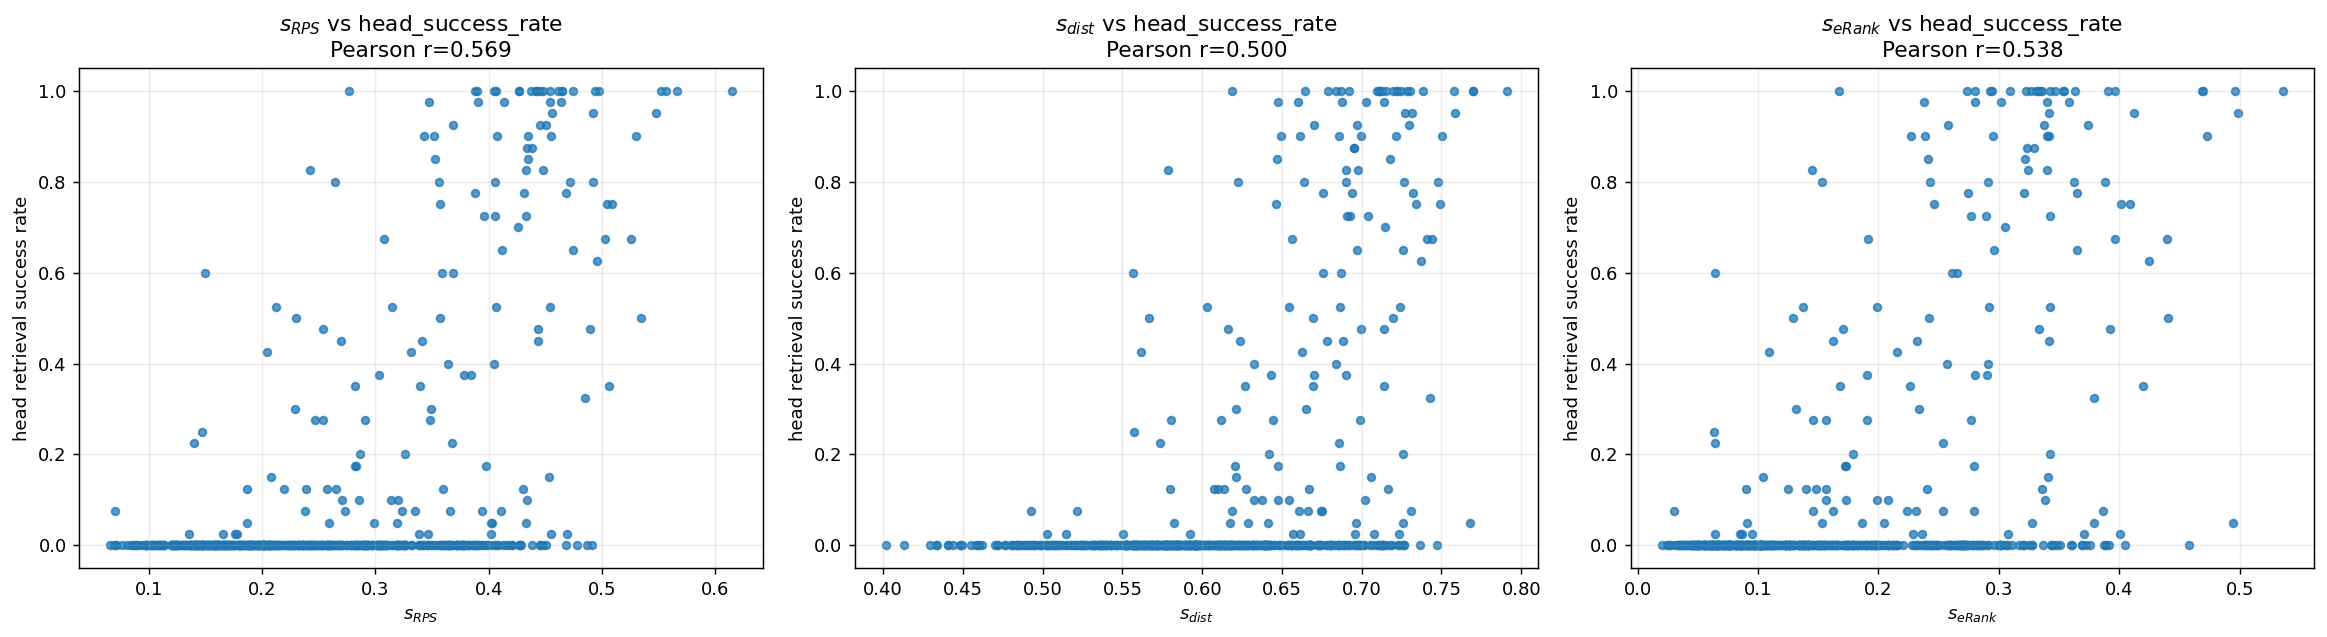

Total aligned heads: 672


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

def normalize_head_key(head_key):
    if isinstance(head_key, tuple) and len(head_key) == 2:
        return int(head_key[0]), int(head_key[1])
    if isinstance(head_key, list) and len(head_key) == 2:
        return int(head_key[0]), int(head_key[1])
    if isinstance(head_key, str):
        nums = re.findall(r"\d+", head_key)
        if len(nums) >= 2:
            return int(nums[0]), int(nums[1])
    return None

lps_map = {normalize_head_key(k): v for k, v in lps_results.items()}
sym_map = {normalize_head_key(k): v for k, v in sym_results.items()}
valid_heads = [k for k in lps_map.keys() if k is not None and k in sym_map]

rows = []
for layer, head in valid_heads:
    if layer < head_success_rate.shape[0] and head < head_success_rate.shape[1]:
        rows.append({
            "head": (layer, head),
            "lps_score": float(lps_map[(layer, head)]["lps_score"] - 0.5 * sym_map[(layer, head)]),
            "raw_energy": float(lps_map[(layer, head)]["raw_energy"]),
            "raw_erank": float(lps_map[(layer, head)]["raw_erank"]),
            "head_success_rate": float(head_success_rate[layer, head].item()),
        })

if not rows:
    raise ValueError("No valid heads found for correlation analysis. Please check the keys in lps_results and sym_results.")

x_specs = [
    ("lps_score", "$s_{LPS}$"),
    ("raw_energy", "$s_{dist}$"),
    ("raw_erank", "$s_{eRank}$"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=130)
for ax, (x_key, x_label) in zip(axes, x_specs):
    x = np.array([r[x_key] for r in rows], dtype=np.float64)
    y = np.array([r["head_success_rate"] for r in rows], dtype=np.float64)
    ax.scatter(x, y, s=18, alpha=0.75)
    if len(x) >= 2 and np.std(x) > 1e-12 and np.std(y) > 1e-12:
        corr = float(np.corrcoef(x, y)[0, 1])
        ax.set_title(f"{x_label} vs head_success_rate\nPearson r={corr:.3f}")
    else:
        ax.set_title(f"{x_label} vs head_success_rate")
    ax.set_xlabel(x_label)
    ax.set_ylabel("head retrieval success rate")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Total aligned heads: {len(rows)}")

In [3]:
from faiss_attn.source.utils import NIAHBuilder
context_builder = NIAHBuilder(tokenizer=tokenizer, haystack_dir="PaulGrahamEssays")
needles = [
    {"needle": "The first band to play on Venus was the Galaxy Melody Band.", "question": "Which band was the first to perform on Mars?", "prefix": "The first band to perform on Mars was the Galaxy", "answer": "Galaxy Melody Band"},
    {"needle": "The ruler of the Polaris star system is Cosmic Ruler Starshine.", "question": "Who is the ruler of the Polaris star system?", "prefix": "The ruler of the Polaris star system is Cosmic", "answer": "Cosmic Ruler Starshine"},
    {"needle": "Hidden on Silent Island is the legendary Dream Bubble.", "question": "What legendary item is hidden on Silent Island?", "prefix": "The legendary item hidden on the Silent Island is the legendary Dream", "answer": "Dream Bubble"},
    {"needle": "Hidden on Golden Island is the legendary Lucky Clover.", "question": "What legendary item is hidden on Golden Island?", "prefix": "The legendary item hidden on the Golden Island is the legendary Lucky", "answer": "Lucky Clover"},
]
top_retrieval_heads = [(14, 22), (2, 16), (14, 2), (14, 1), (5, 7)]
top_induction_heads = [(8, 8), (4, 14), (10, 11), (1, 17), (9, 19)]

In [4]:
import gc
import torch
import pandas as pd
from tqdm.notebook import tqdm

depth_ratios = [i / 10 for i in range(10)]
num_texts_expected = len(needles) * len(depth_ratios)
context_len = 65536
print(f"Total texts to evaluate: {num_texts_expected}")

def find_subsequence_positions(seq, pattern):
    positions = []
    if not pattern or len(pattern) > len(seq):
        return positions
    pat_len = len(pattern)
    for i in range(len(seq) - pat_len + 1):
        if seq[i : i + pat_len] == pattern:
            positions.extend(range(i, i + pat_len))
    return positions

head_success = torch.zeros((n_layers, n_heads), dtype=torch.float32)
total_texts = 0

with torch.no_grad():
    for item in needles:
        for depth_ratio in tqdm(depth_ratios, desc="Evaluating depth ratios"):
            input_str = context_builder.generate_context(
                context_len=context_len,
                depth_ratio=depth_ratio,
                needle_str=item["needle"],
                question_str=item["question"],
            )
            input_str += item["prefix"]

            encoded = tokenizer(input_str, return_tensors="pt", add_special_tokens=False)
            input_ids = encoded.input_ids.to(DEVICE)
            input_ids_list = input_ids[0].tolist()

            ans_ids = tokenizer(item["answer"], add_special_tokens=False).input_ids
            ans_ids_ws = tokenizer(" " + item["answer"], add_special_tokens=False).input_ids

            answer_positions = set(find_subsequence_positions(input_ids_list, ans_ids))
            answer_positions.update(find_subsequence_positions(input_ids_list, ans_ids_ws))

            if len(answer_positions) == 0 or input_ids.shape[1] < 2:
                raise ValueError(
                    f"Answer tokens not found in input_ids for needle '{item['needle']}' with depth_ratio {depth_ratio}. "
                    f"input_ids: {input_ids_list}, ans_ids: {ans_ids}, ans_ids_ws: {ans_ids_ws}"
                )

            prefill_outputs = model.model(input_ids=input_ids[:, :-1], use_cache=True, return_dict=True)
            decode_outputs = model.model(
                input_ids=input_ids[:, -1:],
                past_key_values=prefill_outputs.past_key_values,
                use_cache=True,
                output_attentions=True,
                attn_mode="torch",
            )

            total_texts += 1
            answer_positions = torch.tensor(
                sorted(answer_positions)[:1],
                device=DEVICE,
                dtype=torch.long,
            )

            for layer_idx in range(n_layers):
                attn_last = decode_outputs.attentions[layer_idx][0, :, -1, :]
                topk_indices = torch.topk(attn_last, k=10, dim=-1).indices
                for head_idx in range(n_heads):
                    if torch.isin(topk_indices[head_idx], answer_positions).any().item():
                        head_success[layer_idx, head_idx] += 1

            del decode_outputs, prefill_outputs, input_ids, encoded
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

assert total_texts == num_texts_expected, (
    f"Expected {num_texts_expected} texts, but evaluated {total_texts}."
)

head_success_rate = head_success / total_texts
print(f"Mean success rate across all heads: {head_success_rate.mean().item():.4f}")
top_retrieval_mean = (
    sum(head_success_rate[layer, head].item() for layer, head in top_retrieval_heads)
    / len(top_retrieval_heads)
)
print(f"Mean success rate of top_retrieval_heads: {top_retrieval_mean:.4f}")
top_induction_mean = (
    sum(head_success_rate[layer, head].item() for layer, head in top_induction_heads)
    / len(top_induction_heads)
)
print(f"Mean success rate of top_induction_heads: {top_induction_mean:.4f}")

Total texts to evaluate: 40


Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (148769 > 131072). Running this sequence through the model will result in indexing errors
past_key_values should not be None in from_legacy_cache()


Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating depth ratios:   0%|          | 0/10 [00:00<?, ?it/s]

Mean success rate across all heads: 0.1030
Mean success rate of top_retrieval_heads: 0.1450
Mean success rate of top_induction_heads: 0.6250


#### Plot attention scores

In [17]:
head_rows = []

In [137]:
head_rows.append(rows)

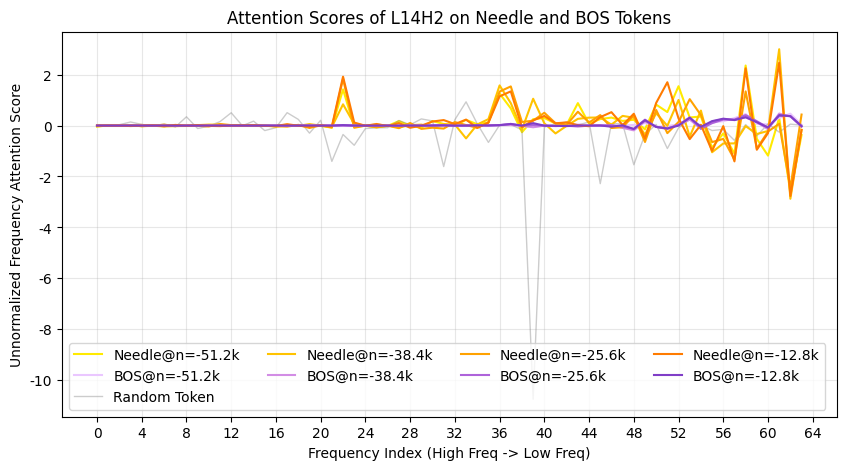

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
target_idx = 32696
random_idx = 52565
for r_i, rows in enumerate(head_rows):
    head_idx = ["n=-51.2k", "n=-38.4k", "n=-25.6k", "n=-12.8k"][r_i]
    c1 = ["#ffea00", "#ffc300", "#ffa200", "#ff7b00"][r_i]
    c2 = ["#eac7ff", "#d28de5", "#ae63da", "#803ec7"][r_i]
    l_target, l_bos, l_random = [], [], []
    for ent in rows:
        for i in range(1, 11):
            if ent[f"pos#{i}"] == target_idx or "watching" in ent[f"token#{i}"]:
                target_idx = ent[f"pos#{i}"]
                l_target.append(float(ent[f"attn#{i}"]))
            if ent[f"pos#{i}"] == 0:
                l_bos.append(float(ent[f"attn#{i}"]))
            if ent[f"pos#{i}"] == random_idx:
                l_random.append(float(ent[f"attn#{i}"]))

    plt.plot(l_target, label=f"Needle@{head_idx}", color=c1, linewidth=1.5)
    plt.plot(l_bos, label=f"BOS@{head_idx}", color=c2, linewidth=1.5)
    # plt.plot(l_random, label="Random Token Attention")
    if r_i == 0:
        plt.plot(pair_attn_weights[5, :, target_idx].cpu().float().numpy(), color="gray", alpha=0.4, linewidth=1, label="Random Token")

# for random_idx in np.random.choice(pair_attn_weights.size(-2), size=5, replace=False):
#     plt.plot(pair_attn_weights[2, :, random_idx].cpu().float().numpy(), color="gray", alpha=0.4, linewidth=1)

plt.xlabel("Frequency Index (High Freq -> Low Freq)")
plt.xticks(np.arange(0, head_dim // 2 + 1, 4))
plt.ylabel("Unnormalized Frequency Attention Score")
plt.title("Attention Scores of L14H2 on Needle and BOS Tokens")
plt.legend(ncol=4)
plt.grid(True, alpha=0.3)
plt.savefig("figs/freq_attn.pdf", bbox_inches='tight')
plt.show()